In [1]:
import matplotlib.pylab as plt 
%matplotlib inline
import numpy as np
import rubin_sim.splat as maf
import pandas as pd
import sqlite3
import healpy as hp
import copy
import datetime

from os.path import basename

In [3]:
db_file = "templates_decpairs_v5.2.0_10yrs.db"
run_name = basename(db_file).replace('.db', '')
con = sqlite3.connect(db_file)
df = pd.read_sql('select * from observations;', con)
con.close()
# Convert to a numpy array
visits_array = df.to_records(index=False)



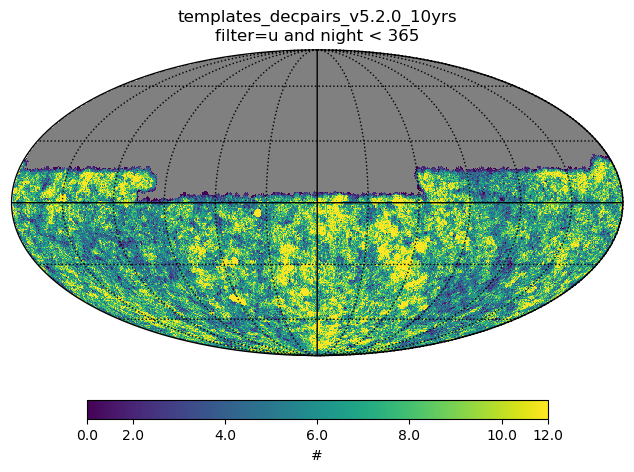

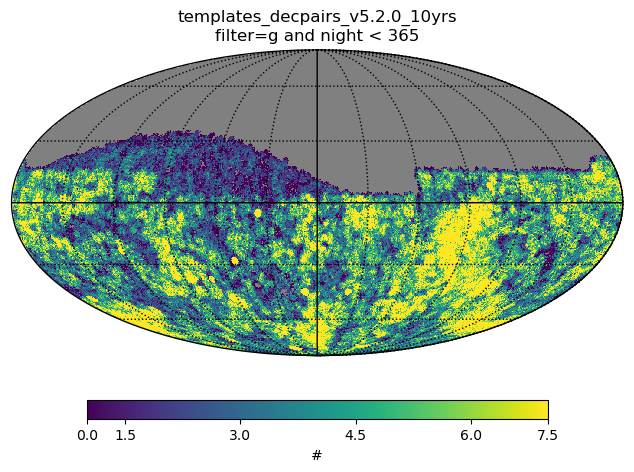

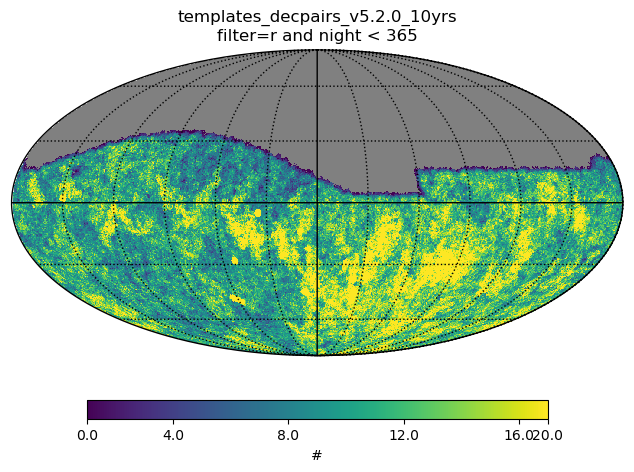

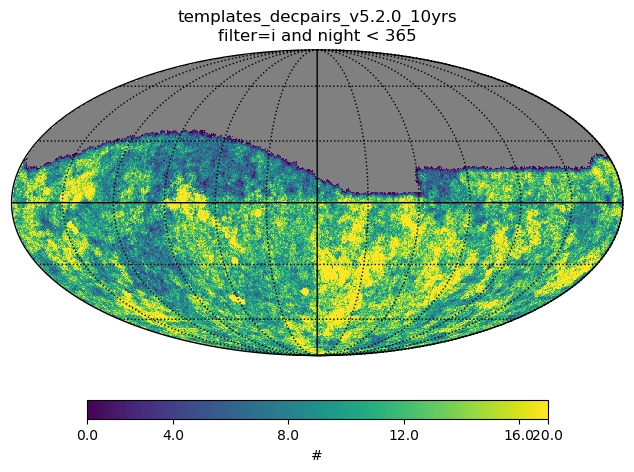

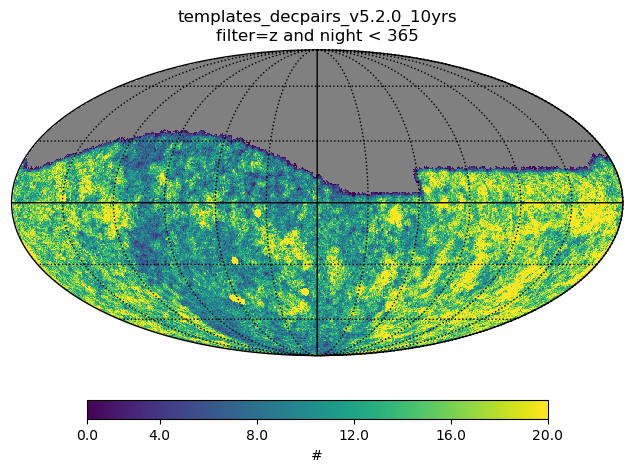

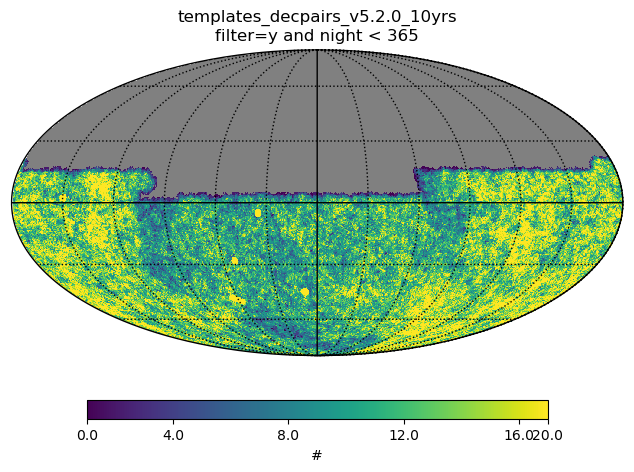

In [4]:
stats = []
for filtername in 'ugrizy':
    info = {"run_name": run_name}
    sub_data = visits_array[np.where((visits_array["band"] == filtername) & (visits_array["night"] < 365))]
    info['observations_subset'] = "filter=%s and night < 365" % (filtername)
    sl = maf.Slicer()
    metric = maf.CountMetric()
    # Run the metics through the slicer
    hp_array, info = sl(sub_data, metric, info=info)
    pm = maf.PlotMoll(info=info)
    fig = pm(hp_array, max=np.percentile(hp_array[np.isfinite(hp_array)], 90))
    stats.append(maf.gen_summary_row(info, "median", np.nanmedian(hp_array)))
    

In [5]:
pd.DataFrame.from_dict(stats)

,run_name,observations_subset,slicer: nside,metric: name,metric: col,metric: unit,summary_name,value
0,templates_decpairs_v5.2.0_10yrs,filter=u and night < 365,128,Count,night,#,median,7.0
1,templates_decpairs_v5.2.0_10yrs,filter=g and night < 365,128,Count,night,#,median,4.0
2,templates_decpairs_v5.2.0_10yrs,filter=r and night < 365,128,Count,night,#,median,11.0
3,templates_decpairs_v5.2.0_10yrs,filter=i and night < 365,128,Count,night,#,median,11.0
4,templates_decpairs_v5.2.0_10yrs,filter=z and night < 365,128,Count,night,#,median,13.0
5,templates_decpairs_v5.2.0_10yrs,filter=y and night < 365,128,Count,night,#,median,12.0
